The goal of the competition is to predict whether or not some users (whose user ids are in the test file) will churn in the window of 10 days that follows the given observations (ie \** after "2018-11-20" *\* ). We consider that a user churns when they visit the page 'Cancellation Confirmation'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os

# ---------- Paths ----------
BASE_PATH = os.getcwd()
sys.path.append(BASE_PATH)

train_path = f"{BASE_PATH}/churn-prediction-25-26/train.parquet"
test_path  = f"{BASE_PATH}/churn-prediction-25-26/test.parquet"

# ---------- Load data ----------
train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

In [3]:
print("=== Loaded files ===")
print(f"train shape: {train.shape}")
print(f"test shape:  {test.shape}\n")
# ---------- Columns & dtypes ----------
print("=== Train columns & dtypes ===")
print(train.dtypes, "\n")

print("=== Test columns & dtypes ===")
print(test.dtypes, "\n")

# ---------- Peek at the data ----------
print("=== Train head ===")
display(train.head())

print("\n=== Test head ===")
display(test.head())

# ---------- Detect datetime-like columns ----------
candidate_time_cols = [
    c for c in train.columns
    if "date" in c.lower() or "time" in c.lower() or "timestamp" in c.lower()
]

print("\n=== Candidate datetime columns in train ===")
print(candidate_time_cols)

=== Loaded files ===
train shape: (17499636, 19)
test shape:  (4393179, 19)

=== Train columns & dtypes ===
status                    int64
gender                   object
firstName                object
level                    object
lastName                 object
userId                   object
ts                        int64
auth                     object
page                     object
sessionId                 int64
location                 object
itemInSession             int64
userAgent                object
method                   object
length                  float64
song                     object
artist                   object
time             datetime64[us]
registration     datetime64[us]
dtype: object 

=== Test columns & dtypes ===
status                    int64
gender                   object
firstName                object
level                    object
lastName                 object
userId                   object
ts                        int64
auth          

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
0,200,M,Shlok,paid,Johnson,1749042,1538352001000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",278,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,524.32934,Ich mache einen Spiegel - Dream Part 4,Popol Vuh,2018-10-01 00:00:01,2018-08-08 13:22:21
992,200,M,Shlok,paid,Johnson,1749042,1538352525000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",279,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,178.02404,Monster (Album Version),Skillet,2018-10-01 00:08:45,2018-08-08 13:22:21
1360,200,M,Shlok,paid,Johnson,1749042,1538352703000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",280,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,232.61995,Seven Nation Army,The White Stripes,2018-10-01 00:11:43,2018-08-08 13:22:21
1825,200,M,Shlok,paid,Johnson,1749042,1538352935000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",281,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,265.50812,Under The Bridge (Album Version),Red Hot Chili Peppers,2018-10-01 00:15:35,2018-08-08 13:22:21
2366,200,M,Shlok,paid,Johnson,1749042,1538353200000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",282,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,471.69261,Circlesong 6,Bobby McFerrin,2018-10-01 00:20:00,2018-08-08 13:22:21



=== Test head ===


,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
7,200,M,Jonathan,free,Martin,1465194,1538352006000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",29,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,250.82730,Mockingbird,Eminem,2018-10-01 00:00:06,2018-09-27 17:29:36
54,200,M,Jonathan,free,Martin,1465194,1538352028000,Logged In,Roll Advert,22483,"New York-Newark-Jersey City, NY-NJ-PA",30,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-01 00:00:28,2018-09-27 17:29:36
477,200,M,Jonathan,free,Martin,1465194,1538352256000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",31,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,355.78730,Thank You (Precious Memories Album Version),Ray Boltz,2018-10-01 00:04:16,2018-09-27 17:29:36
1170,200,M,Jonathan,free,Martin,1465194,1538352611000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",32,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,191.68608,Mathletics,Foals,2018-10-01 00:10:11,2018-09-27 17:29:36
1552,200,M,Jonathan,free,Martin,1465194,1538352802000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",33,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,275.25179,Proceed,The Roots,2018-10-01 00:13:22,2018-09-27 17:29:36



=== Candidate datetime columns in train ===
['time']


In [4]:
# ---------- Unique pages ----------
print("\n=== Unique pages in train dataset ===")
train.page.unique()


=== Unique pages in train dataset ===


array(['NextSong', 'Downgrade', 'Help', 'Home', 'Thumbs Up', 'Add Friend',
       'Thumbs Down', 'Add to Playlist', 'Logout', 'About', 'Settings',
       'Save Settings', 'Cancel', 'Cancellation Confirmation',
       'Submit Downgrade', 'Roll Advert', 'Upgrade', 'Error',
       'Submit Upgrade'], dtype=object)

In [5]:
# ---------- Example query ----------
print("\n=== Example query for userId '1749042' ===")
train.query("userId == '1749042'")


=== Example query for userId '1749042' ===


,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
0,200,M,Shlok,paid,Johnson,1749042,1538352001000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",278,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,524.32934,Ich mache einen Spiegel - Dream Part 4,Popol Vuh,2018-10-01 00:00:01,2018-08-08 13:22:21
992,200,M,Shlok,paid,Johnson,1749042,1538352525000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",279,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,178.02404,Monster (Album Version),Skillet,2018-10-01 00:08:45,2018-08-08 13:22:21
1360,200,M,Shlok,paid,Johnson,1749042,1538352703000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",280,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,232.61995,Seven Nation Army,The White Stripes,2018-10-01 00:11:43,2018-08-08 13:22:21
1825,200,M,Shlok,paid,Johnson,1749042,1538352935000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",281,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,265.50812,Under The Bridge (Album Version),Red Hot Chili Peppers,2018-10-01 00:15:35,2018-08-08 13:22:21
2366,200,M,Shlok,paid,Johnson,1749042,1538353200000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",282,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,471.69261,Circlesong 6,Bobby McFerrin,2018-10-01 00:20:00,2018-08-08 13:22:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6660411,307,M,Shlok,paid,Johnson,1749042,1540083704000,Logged In,Logout,100362,"Dallas-Fort Worth-Arlington, TX",56,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,NaN,None,None,2018-10-21 01:01:44,2018-08-08 13:22:21
6661269,200,M,Shlok,paid,Johnson,1749042,1540084093000,Logged In,Home,100362,"Dallas-Fort Worth-Arlington, TX",59,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-21 01:08:13,2018-08-08 13:22:21
6661525,200,M,Shlok,paid,Johnson,1749042,1540084193000,Logged In,Downgrade,100362,"Dallas-Fort Worth-Arlington, TX",60,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-21 01:09:53,2018-08-08 13:22:21
6661531,307,M,Shlok,paid,Johnson,1749042,1540084194000,Logged In,Cancel,100362,"Dallas-Fort Worth-Arlington, TX",61,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,NaN,None,None,2018-10-21 01:09:54,2018-08-08 13:22:21


In [8]:
# ---------- Page visit counts ----------
page_count = train['page'].value_counts().sort_values(ascending=False)
print("\n=== Page visit counts ===")
print (page_count)
train.time.max(), train.time.min()


=== Page visit counts ===
page
NextSong                     14291433
Thumbs Up                      789391
Home                           645259
Add to Playlist                409606
Roll Advert                    284837
Add Friend                     262147
Logout                         204700
Thumbs Down                    164964
Downgrade                      124248
Settings                       101191
Help                            89035
Upgrade                         37696
About                           33117
Save Settings                   20370
Error                           17294
Submit Upgrade                  11381
Submit Downgrade                 4425
Cancellation Confirmation        4271
Cancel                           4271
Name: count, dtype: int64


(Timestamp('2018-11-20 00:00:00'), Timestamp('2018-10-01 00:00:01'))

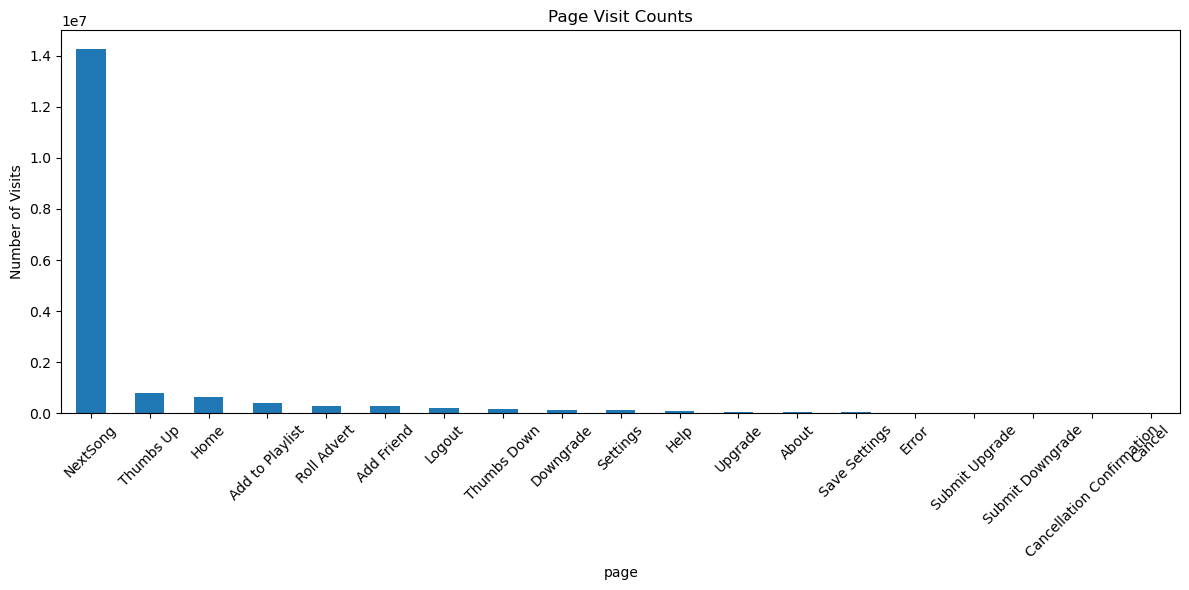

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
page_count.plot(kind='bar')
plt.title("Page Visit Counts")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
train = train.sort_values(by = ['userId', 'time'])

In [6]:
train.loc[train['page'] == 'Cancellation Confirmation']


,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
5929703,200,M,Camren,paid,Walker,1000025,1539894785000,Cancelled,Cancellation Confirmation,95858,"New Haven-Milford, CT",120,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-18 20:33:05,2018-07-10 09:30:08
3771849,200,M,Grady,paid,Jensen,1000083,1539338698000,Cancelled,Cancellation Confirmation,72494,"Cincinnati, OH-KY-IN",148,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-12 10:04:58,2018-09-07 18:01:49
22478579,200,M,Frank,free,Warren,1000280,1542149985000,Cancelled,Cancellation Confirmation,25840,"Findlay, OH",138,Mozilla/5.0 (Windows NT 5.1; rv:31.0) Gecko/20...,GET,NaN,None,None,2018-11-13 22:59:45,2018-08-28 15:42:19
7191245,200,F,Phoebe,paid,Frederick,1000353,1540247149000,Cancelled,Cancellation Confirmation,35478,"Wichita Falls, TX",111,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-22 22:25:49,2018-05-02 11:37:39
21576634,200,F,Saraya,paid,Anderson,1000503,1539396428000,Cancelled,Cancellation Confirmation,7092,"Boston-Cambridge-Newton, MA-NH",140,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,GET,NaN,None,None,2018-10-13 02:07:08,2018-06-30 11:05:49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20793185,200,M,Nicholas,paid,Gordon,1999022,1541304586000,Cancelled,Cancellation Confirmation,16078,"New York-Newark-Jersey City, NY-NJ-PA",138,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",GET,NaN,None,None,2018-11-04 04:09:46,2018-09-22 21:31:14
19896794,200,M,Jax,free,Evans,1999035,1538398263000,Cancelled,Cancellation Confirmation,3257,"Stephenville, TX",10,Mozilla/5.0 (Windows NT 6.0; rv:31.0) Gecko/20...,GET,NaN,None,None,2018-10-01 12:51:03,2018-04-29 14:07:05
19931917,200,F,Tessa,free,Powell,1999668,1538450578000,Cancelled,Cancellation Confirmation,2279,"Beaumont-Port Arthur, TX",51,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-02 03:22:58,2018-09-03 11:44:46
20458613,200,F,Khloe,paid,Kelley,1999847,1539828646000,Cancelled,Cancellation Confirmation,11005,"Columbus, OH",266,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-18 02:10:46,2018-09-26 04:22:19


In [9]:
train.time.max(), train.time.min()

(Timestamp('2018-11-20 00:00:00'), Timestamp('2018-10-01 00:00:01'))

In [12]:
user_times = train.groupby('userId')['time'].agg(['min', 'max']).reset_index()
user_times = user_times.rename(columns={'min': 'mintime', 'max': 'maxtime'})


In [12]:
user_times_test = test.groupby('userId')['time'].agg(['min', 'max']).reset_index()
user_times_test = user_times_test.rename(columns={'min': 'mintime', 'max': 'maxtime'})

In [11]:
user_times

,userId,mintime,maxtime
0,1000025,2018-10-02 08:59:29,2018-10-18 20:33:05
1,1000035,2018-10-05 18:29:46,2018-11-15 03:53:11
2,1000083,2018-10-01 05:37:45,2018-10-12 10:04:58
3,1000103,2018-10-04 17:31:17,2018-11-08 18:28:40
4,1000164,2018-10-01 17:40:18,2018-11-19 13:04:25
...,...,...,...
19135,1999781,2018-10-01 05:53:44,2018-11-19 16:41:31
19136,1999847,2018-10-04 17:19:17,2018-10-18 02:10:46
19137,1999848,2018-10-01 14:36:05,2018-11-18 06:28:48
19138,1999892,2018-10-05 15:34:27,2018-10-26 22:26:14


In [15]:
user_times.query('maxtime < "2018-11-10"')

,userId,mintime,maxtime
0,1000025,2018-10-02 08:59:29,2018-10-18 20:33:05
2,1000083,2018-10-01 05:37:45,2018-10-12 10:04:58
3,1000103,2018-10-04 17:31:17,2018-11-08 18:28:40
6,1000182,2018-10-19 22:47:56,2018-11-09 23:50:22
10,1000244,2018-10-07 01:03:12,2018-10-07 01:06:48
...,...,...,...
19126,1999035,2018-10-01 12:27:55,2018-10-01 12:51:03
19133,1999382,2018-10-03 10:31:10,2018-10-03 12:47:39
19134,1999668,2018-10-02 00:46:00,2018-10-02 03:22:58
19136,1999847,2018-10-04 17:19:17,2018-10-18 02:10:46


In [13]:
user_times_test

,userId,mintime,maxtime
0,1000655,2018-10-03 09:00:59,2018-11-15 18:14:51
1,1000963,2018-10-04 23:29:51,2018-11-18 00:08:19
2,1001129,2018-10-02 01:28:58,2018-11-18 22:56:10
3,1001963,2018-10-10 06:49:13,2018-11-19 20:39:31
4,1002283,2018-10-01 20:10:56,2018-11-19 18:17:18
...,...,...,...
2899,1999455,2018-10-07 17:10:03,2018-11-16 17:42:49
2900,1999691,2018-10-08 13:12:22,2018-11-17 01:57:44
2901,1999720,2018-10-05 12:52:44,2018-11-15 10:33:37
2902,1999908,2018-10-01 00:02:20,2018-11-18 07:51:05


In [15]:
# Ensure time column is in datetime with ms precision
train["time"] = pd.to_datetime(train["time"], unit="ms")

# Extract date
train["date"] = train["time"].dt.date

# Group by date and count rows
daily_counts = (
    train.groupby("date")
         .size()
         .reset_index(name="count")
         .sort_values("date")
)

Text(0, 0.5, 'Number of Events')

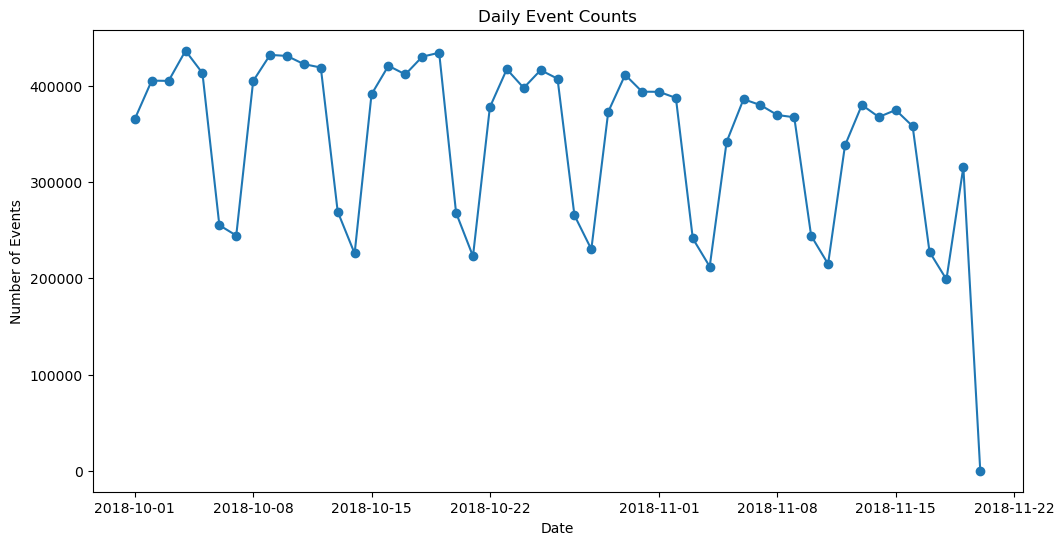

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(daily_counts["date"], daily_counts["count"], marker='o')
plt.title("Daily Event Counts")
plt.xlabel("Date")
plt.ylabel("Number of Events")